# ==========================================================
# End-to-End Image Classification Pipeline
# - Dataset preparation (train/val/test split)
# - Advanced augmentation (scale, luminance, intensity, noise, orientation, size)
# - Model (from scratch CNN)
# - Training with checkpoints (best model saving)
# - Evaluation (test set, confusion matrix, classification report)
# - Visualization (accuracy/loss curves)
# - Grad-CAM
# ==========================================================

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Segmented Kaggle brain tumour dataset 2023 7023"

TRAIN_PATH = f"{DATASET_PATH}/train"
VAL_PATH   = f"{DATASET_PATH}/val"
TEST_PATH  = f"{DATASET_PATH}/test"

MODEL_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5"

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_PATH,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 4914 files belonging to 4 classes.
Found 1052 files belonging to 4 classes.
Found 1057 files belonging to 4 classes.
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']


In [4]:
def to_rgb(image, label):
    image = tf.image.grayscale_to_rgb(image)
    return image, label

train_ds = train_ds.map(to_rgb)
val_ds   = val_ds.map(to_rgb)
test_ds  = test_ds.map(to_rgb)

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential([

    # ✅ Safe spatial augmentations
    tf.keras.layers.RandomFlip("horizontal"),   # MRI is usually symmetric enough
    tf.keras.layers.RandomRotation(0.05),

    # ✅ Slight zoom (simulate scanner variation)
    tf.keras.layers.RandomZoom(0.1),

    # ✅ Slight translation (position robustness)
    tf.keras.layers.RandomTranslation(0.05, 0.05),

    # ✅ Intensity variations (IMPORTANT for MRI)
    tf.keras.layers.RandomContrast(0.1),

    # ✅ Add low noise
    tf.keras.layers.GaussianNoise(0.02),

    # ✅ Brightness augmentation (simulate scanner differences)
    tf.keras.layers.Lambda(
    lambda x: tf.image.random_brightness(x, 0.1)
)
])

In [7]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:   # 🔥 keep last 20 layers trainable
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
base_model.trainable = False

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [11]:
from sklearn.utils.class_weight import compute_class_weight


callbacks = [

    # ✅ Save best model (based on val_loss)
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),

    # ✅ Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,             # stop after 5 bad epochs
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)
]

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5166 - loss: 1.4258
Epoch 1: val_loss improved from None to 0.46329, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 774s 1s/step - accuracy: 0.6378 - loss: 1.0505 - val_accuracy: 0.8356 - val_loss: 0.4633 - learning_rate: 1.0000e-04
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7782 - loss: 0.6040
Epoch 2: val_loss improved from 0.46329 to 0.35533, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.7975 - loss: 0.5661 - val_accuracy: 0.8679 - val_loss: 0.3553 - learning_rate: 1.0000e-04
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8299 - loss: 0.4703
Epoch 3: val_loss improved from 0.35533 to 0.30650, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.8376 - loss: 0.4388 - val_accuracy: 0.8897 - val_loss: 0.3065 - learning_rate: 1.0000e-04
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8643 - loss: 0.3593
Epoch 4: val_loss improved from 0.30650 to 0.26180, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.8704 - loss: 0.3412 - val_accuracy: 0.9059 - val_loss: 0.2618 - learning_rate: 1.0000e-04
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8784 - loss: 0.3209
Epoch 5: val_loss improved from 0.26180 to 0.23434, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.9088 - loss: 0.2526 - val_accuracy: 0.9259 - val_loss: 0.1929 - learning_rate: 1.0000e-04
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9081 - loss: 0.2399
Epoch 7: val_loss improved from 0.19288 to 0.17116, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.9182 - loss: 0.2236 - val_accuracy: 0.9382 - val_loss: 0.1712 - learning_rate: 1.0000e-04
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9206 - loss: 0.2036
Epoch 8: val_loss improved from 0.17116 to 0.15958, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.9217 - loss: 0.2023 - val_accuracy: 0.9392 - val_loss: 0.1596 - learning_rate: 1.0000e-04
Epoch 9/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9263 - loss: 0.2051
Epoch 9: val_loss did not improve from 0.15958
154/154 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.9328 - loss: 0.1855 - val_accuracy: 0.9306 - val_loss: 0.1732 - learning_rate: 1.0000e-04
Epoch 10/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9407 - loss: 0.1653
Epoch 10: val_loss improved from 0.15958 to 0.13744, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.9375 - loss: 0.1734 - val_accuracy: 0.9458 - val_loss: 0.1374 - learning_rate: 1.0000e-04
Epoch 11/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9411 - loss: 0.1607
Epoch 11: val_loss did not improve from 0.13744
154/154 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.9477 - loss: 0.1496 - val_accuracy: 0.9487 - val_loss: 0.1388 - learning_rate: 1.0000e-04
Epoch 12/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9477 - loss: 0.1354
Epoch 12: val_loss improved from 0.13744 to 0.11206, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5



Epoch 12: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.9479 - loss: 0.1375 - val_accuracy: 0.9572 - val_loss: 0.1121 - learning_rate: 1.0000e-04
Epoch 13/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9542 - loss: 0.1269
Epoch 13: val_loss did not improve from 0.11206
154/154 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.9550 - loss: 0.1274 - val_accuracy: 0.9430 - val_loss: 0.1474 - learning_rate: 1.0000e-04
Epoch 14/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9514 - loss: 0.1306
Epoch 14: val_loss did not improve from 0.11206
154/154 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.9556 - loss: 0.1220 - val_accuracy: 0.9477 - val_loss: 0.1347 - learning_rate: 1.0000e-04
Epoch 15/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9607 - loss: 0.1036
Epoch 15: val_loss did not improve from 0.11206
154/154 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - a

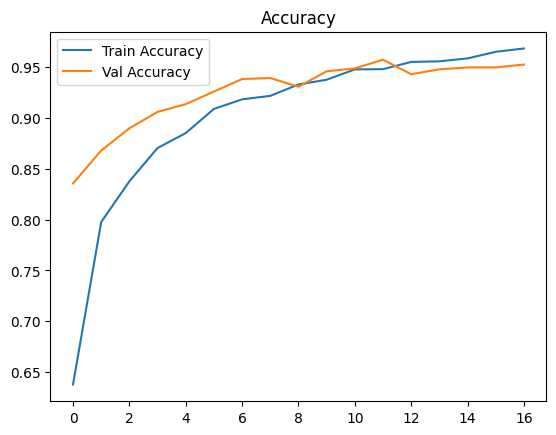

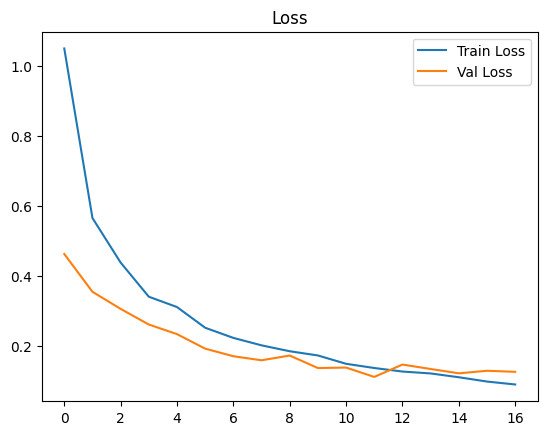

In [13]:
# ==========================================================
# Plot Training History
# ==========================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.figure()
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [14]:
# ==========================================================
# Evaluation on Test Set
# ==========================================================
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))





1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

              precision    recall  f1-score   support

      glioma       0.93      0.94      0.94       244
     healthy       0.99      0.99      0.99       300
  meningioma       0.95      0.85      0.90       248
   pituitary       0.92      1.00      0.95       265

    accuracy                           0.95      1057
   macro avg       0.95      0.95      0.95      1057
weighted avg       0.95      0.95      0.95      1057



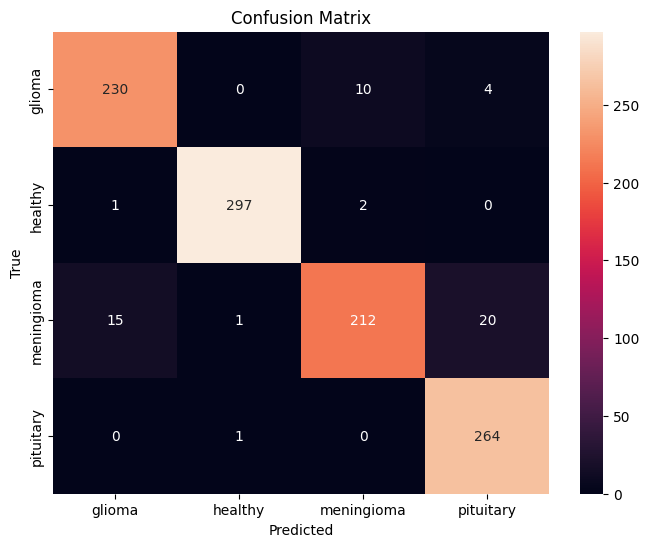

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
def get_gradcam_heatmap(model, image, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [17]:
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    return superimposed_img

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,255,185 (27.68 MB)

 Trainable params: 1,518,004 (5.79 MB)

 Non-trainable params: 2,701,171 (10.30 MB)

 Optimizer params: 3,036,010 (11.58 MB)

In [19]:
for images, labels in test_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

# Expand dims for model input
input_image = tf.expand_dims(sample_image, axis=0)

# 🔥 IMPORTANT: choose correct last conv layer
last_conv_layer_name = "top_conv"  # EfficientNet

heatmap = get_gradcam_heatmap(model, input_image, last_conv_layer_name)

ValueError: No such layer: top_conv. Existing layers are: ['sequential', 'efficientnetb0', 'global_average_pooling2d', 'dropout', 'batch_normalization', 'dense', 'dropout_1', 'dense_1'].

In [ ]:
img = sample_image.numpy()

# If normalized, bring back to 0-255
img = (img * 255).astype(np.uint8)

In [ ]:
gradcam_img = overlay_gradcam(img, heatmap)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gradcam_img)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()